<a href="https://colab.research.google.com/github/kalex066/RetailSales_DataAnalysis/blob/development/notebooks/RetailSales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto I
## Análisis y Predicción de Ventas en una Tienda de Retail

### Análisis Exploratorio con Pandas

Las dos partes del proyecto las realice con Pandas en lugar de NumPy. Empezare con el analisis exploratorio utilizando pandas, que corresponde a la parte II del proyecto, y al final se encuentran los calculos adicionales que se solicitaban en la parte I con Numpy

# Carga de Datos

In [2]:
import pandas as pd
df_rs = pd.read_csv('/content/sample_data/retail_sales_dataset.csv')

# Exploración Inicial de los Datos

In [3]:
# Shape
print(f"Shape: {df_rs.shape}\n")

Shape: (1000, 9)



In [4]:
# Primeras 10 filas
print(df_rs.head(10))

   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   
5               6  2023-04-25     CUST006  Female   45           Beauty   
6               7  2023-03-13     CUST007    Male   46         Clothing   
7               8  2023-02-22     CUST008    Male   30      Electronics   
8               9  2023-12-13     CUST009    Male   63      Electronics   
9              10  2023-10-07     CUST010  Female   52         Clothing   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30 

In [5]:
# Tipos de datos
df_rs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [6]:
# Estadisticas Descriptivas
df_rs.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [7]:
# ultimas filas
df_rs.tail(5)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


# Inspeccion de Datos

In [8]:
# Tipos de datos
print("Tipos de datos por columna:")
print(df_rs.dtypes)

Tipos de datos por columna:
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object


In [9]:
# Valores unicos en la columna producto
print(df_rs['Product Category'].value_counts())

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64


In [10]:
# valores unicos en la columna tienda
'''El dataset no tiene columna tienda, puedo utilizar la columna de categoria para crear tiendas
asumiendo que cada categoria es una tienda, por ejemplo, si el producto es clothing es tienda de
ropa, si el producto es beuty es una tienda de belleza, y asi..'''
def tienda_por_categoria(category):
  if category == "Clothing":
    return "Clothing Store"
  elif category == "Electronics":
    return "Electronic Store"
  else:
    return "Beauty Store"

# defino la columna tienda en el dataframe
df_rs['Tienda'] = df_rs['Product Category'].apply(tienda_por_categoria)

# valores unicos
print(df_rs['Tienda'].unique())



['Beauty Store' 'Clothing Store' 'Electronic Store']


In [11]:
# Tambien podria hacerlo directamente aplicando unique a la columna Product Category
print(df_rs['Product Category'].unique())

['Beauty' 'Clothing' 'Electronics']


# Filtrado de Datos

In [12]:
# mostrar solo las filas donde las ventas sean mayores a 50.
ventas_mayores = df_rs[df_rs['Total Amount']> 50]
print(f'Hay {len(ventas_mayores)} registros de ventas mayores a 50')
ventas_mayores.head()


Hay 783 registros de ventas mayores a 50


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Tienda
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,Beauty Store
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,Clothing Store
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,Clothing Store
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,Beauty Store
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100,Electronic Store


In [13]:
# mostrar solo las filas donde el precio  sea menor a 0.5
ventas_menores = df_rs[df_rs['Price per Unit'] < 0.5 ]
print(f'Hay {len(ventas_menores)} registros de ventas menores a 0.5')
ventas_menores.head()

Hay 0 registros de ventas menores a 0.5


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Tienda


In [14]:
# Utilizando el método query(), filtra el DataFrame para mostrar las filas donde el producto sea Manzanas y las ventas sean mayores a 30.

'''El dataset no tiene productos manzana, las categorias de producto son Beauty, Clothing y
Electronics. Para practicar el filtro, buscare los Product Category Beauty con ventas > 30'''

ventas_beauty_30 = df_rs.query("`Product Category` == 'Beauty' and `Total Amount` > 30")
print(f"Hay {len(ventas_beauty_30)} registros donde la Categoria es Beauty y las ventas son mayores a 30")
ventas_beauty_30.head()

Hay 273 registros donde la Categoria es Beauty y las ventas son mayores a 30


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Tienda
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,Beauty Store
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,Beauty Store
11,12,2023-10-30,CUST012,Male,35,Beauty,3,25,75,Beauty Store
20,21,2023-01-14,CUST021,Female,50,Beauty,1,500,500,Beauty Store
24,25,2023-12-26,CUST025,Female,64,Beauty,1,50,50,Beauty Store


# Slicing de Datos

In [15]:
# Selecciona y muestra solo las columnas Producto y Ventas del DataFrame.
df1 = df_rs[['Product Category', 'Total Amount']]
df1.head()

,Product Category,Total Amount
0,Beauty,150
1,Clothing,1000
2,Electronics,30
3,Clothing,500
4,Beauty,100


In [16]:
# Utilizando loc[], selecciona y muestra las filas de la 5 a la 10 (inclusive) y las columnas Producto y Tienda.

df2 = df_rs.loc[5:10, ['Product Category', 'Total Amount']]
df2


,Product Category,Total Amount
5,Beauty,30
6,Clothing,50
7,Electronics,100
8,Electronics,600
9,Clothing,200
10,Clothing,100


In [17]:
# Utilizando iloc[], selecciona y muestra las primeras 5 filas y las primeras 3 columnas del DataFrame

df3 = df_rs.iloc[:5, :3]
df3

,Transaction ID,Date,Customer ID
0,1,2023-11-24,CUST001
1,2,2023-02-27,CUST002
2,3,2023-01-13,CUST003
3,4,2023-05-21,CUST004
4,5,2023-05-06,CUST005


#En esta parte voy a codificar los requerimientos de la parte I del proyecto, con pandas

## Exploracion de Datos

In [18]:
# Calcula el total de ventas por categoría de producto
totalventas_por_categoria = df_rs.groupby('Product Category')['Total Amount'].sum()
print(totalventas_por_categoria)

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64


In [19]:
# Calcula el promedio de ventas diarias por categoría de producto.
ventas_diarias = df_rs.groupby(['Product Category', 'Date'])['Total Amount'].sum()
promedio_ventas_diario = ventas_diarias.groupby('Product Category').mean()
print(promedio_ventas_diario)

Product Category
Beauty         703.504902
Clothing       670.603448
Electronics    716.461187
Name: Total Amount, dtype: float64


In [20]:
# Identifica las categorías de productos con mayores y menores ventas.
mayor_y_menor_venta = df_rs.groupby('Product Category')['Total Amount'].sum().describe()
print(mayor_y_menor_venta)

'''comparando los valores con el resultado del codigo anterior (suma total por categoria) puedo ver
el resultado, pero como quiero que me aparezcan los nombres, intentare otra forma'''
categoria_mayor_venta = totalventas_por_categoria.idxmax()
maximo = totalventas_por_categoria.max()

categoria_menor_venta = totalventas_por_categoria.idxmin()
minimo = totalventas_por_categoria.min()
print(f' La categoria de producto de mayor venta es: {categoria_mayor_venta} con un valor de $ {maximo}')
print(f' La categoria de producto de menor venta es: {categoria_menor_venta} con un valor de $ {minimo}')


count         3.000000
mean     152000.000000
std        7378.029886
min      143515.000000
25%      149547.500000
50%      155580.000000
75%      156242.500000
max      156905.000000
Name: Total Amount, dtype: float64
 La categoria de producto de mayor venta es: Electronics con un valor de $ 156905
 La categoria de producto de menor venta es: Beauty con un valor de $ 143515


# Manipulacion de Datos

In [21]:
# Filtra los datos para mostrar solo las ventas de una categoría de producto especí
categoria = 'Clothing'
df_categoria = df_rs[df_rs['Product Category'] == categoria]

print(f"Las ventas de la categoria {categoria} son: \n {df_categoria['Total Amount'].head(10)}")


Las ventas de la categoria Clothing son: 
 1     1000
3      500
6       50
9      200
10     100
13     120
15    1500
16     100
18      50
19     900
Name: Total Amount, dtype: int64


In [22]:
# Realiza operaciones de suma, resta, multiplicación y división en los datos para obtener estadísticas adicionales.

#sumo las ventas de una categoria especifica
total_ventas_categoria = df_categoria['Total Amount'].sum()
print(f"La suma de las ventas de la categoría {categoria} es: {total_ventas_categoria:,.2f}")

# se le aplica un descuento de 25% a una categoria especifica (aplico resta y multiplicacion)
descuento = 0.25
monto_descuento = total_ventas_categoria * descuento
ventas_con_descuento = total_ventas_categoria - monto_descuento
print(f"Las ventas de la categoria {categoria} despues de aplicarles el descuento de 25% son de {ventas_con_descuento}")

# calculo promedio de articulos por venta de una categoria especifica
unidades = df_categoria['Quantity'].sum()
numero_transacciones = len(df_categoria)
unidades_por_boleta = unidades / numero_transacciones
print(f"En la categoría {categoria}, los clientes compran en promedio {unidades_por_boleta:.1f} unidades cada vez")

La suma de las ventas de la categoría Clothing es: 155,580.00
Las ventas de la categoria Clothing despues de aplicarles el descuento de 25% son de 116685.0
En la categoría Clothing, los clientes compran en promedio 2.5 unidades cada vez


# PARTE III

La parte 3 comienza con transformacion de datos, sin embargo, antes de empezar con ella voy a hacer la limpieza de los mismos

# Limpieza de Datos

In [23]:
# Eliminar columnas irrelevantes, id de la transaccion, a partir de aqui creare otro dataframe
df_rs2 = df_rs.drop(columns=['Transaction ID'])
print(f" Data sin columnas con info de Id's:   {df_rs2.shape}")


 Data sin columnas con info de Id's:   (1000, 9)


In [24]:
# determinar cantidad de nulos por columna
print(df_rs2.isnull().sum())


Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
Tienda              0
dtype: int64


In [25]:
# Eliminar duplicados
df_rs2= df_rs2.drop_duplicates()
print(f"Data sin duplicados: {df_rs2.shape}")

Data sin duplicados: (1000, 9)


In [26]:
# Convertir tipos
# date a datetime
df_rs2['Date'] = pd.to_datetime(df_rs2['Date'])

# Gender, Product Category y Tienda de object a category por tener valores fijos en la categoria
df_rs2['Gender'] = df_rs2['Gender'].astype('category')
df_rs2['Product Category'] = df_rs2['Product Category'].astype('category')
df_rs2['Tienda'] = df_rs2['Tienda'].astype('category')

# Price per unit y total amount de integer a float ya que los precios y cantidades a pagar suelen ser decimales
df_rs2['Price per Unit'] = df_rs2['Price per Unit'].astype(float)
df_rs2['Total Amount'] = df_rs2['Total Amount'].astype(float)


In [27]:
# Renombrar - cambiare los nombres a espanol, solo por practicar
df_rs2= df_rs2.rename(columns={
    'Date': 'Fecha',
    'Customer ID': 'ID_Cliente',
    'Gender': 'Genero',
    'Age': 'Edad',
    'Product Category': 'Categoria_de_Producto',
    'Quantity': 'Cantidad',
    'Price per Unit': 'Precio_por_unidad',
    'Total Amount': 'Total_de_Ventas'
})


In [28]:
print(f"\n✅ Dataset limpio:")
print(df_rs2.dtypes)
df_rs2.head()


✅ Dataset limpio:
Fecha                    datetime64[ns]
ID_Cliente                       object
Genero                         category
Edad                              int64
Categoria_de_Producto          category
Cantidad                          int64
Precio_por_unidad               float64
Total_de_Ventas                 float64
Tienda                         category
dtype: object


,Fecha,ID_Cliente,Genero,Edad,Categoria_de_Producto,Cantidad,Precio_por_unidad,Total_de_Ventas,Tienda
0,2023-11-24,CUST001,Male,34,Beauty,3,50.0,150.0,Beauty Store
1,2023-02-27,CUST002,Female,26,Clothing,2,500.0,1000.0,Clothing Store
2,2023-01-13,CUST003,Male,50,Electronics,1,30.0,30.0,Electronic Store
3,2023-05-21,CUST004,Male,37,Clothing,1,500.0,500.0,Clothing Store
4,2023-05-06,CUST005,Male,30,Beauty,2,50.0,100.0,Beauty Store


# Transformación de Datos


# Crear nuevas columnas / Clasificar Datos
Pensando en un analisis de ventas por  mes, o ventas por dia de la semana vs ventas en fin de semana, a partir de los valores de Date, creare columnas del mes, y dia

In [29]:
# extraigo y creo la columna mes
df_rs2['Mes'] = df_rs2['Fecha'].dt.month_name()

# extraigo y creo la columan dia
df_rs2['Dia'] = df_rs2['Fecha'].dt.day_name()

df_rs2.head(3)

,Fecha,ID_Cliente,Genero,Edad,Categoria_de_Producto,Cantidad,Precio_por_unidad,Total_de_Ventas,Tienda,Mes,Dia
0,2023-11-24,CUST001,Male,34,Beauty,3,50.0,150.0,Beauty Store,November,Friday
1,2023-02-27,CUST002,Female,26,Clothing,2,500.0,1000.0,Clothing Store,February,Monday
2,2023-01-13,CUST003,Male,50,Electronics,1,30.0,30.0,Electronic Store,January,Friday


Clasificacion de datos (dias de la semana) para luego evaluar si los dias son laborales o fin de semana

In [30]:
# Clasificamos entre Días Hábiles y Fin de Semana
df_rs2['Periodo_Semana'] = df_rs2['Dia'].apply(
    lambda x: 'Fin de Semana' if x in ['Saturday', 'Sunday'] else 'Día Laboral'
)
df_rs2.head(3)

,Fecha,ID_Cliente,Genero,Edad,Categoria_de_Producto,Cantidad,Precio_por_unidad,Total_de_Ventas,Tienda,Mes,Dia,Periodo_Semana
0,2023-11-24,CUST001,Male,34,Beauty,3,50.0,150.0,Beauty Store,November,Friday,Día Laboral
1,2023-02-27,CUST002,Female,26,Clothing,2,500.0,1000.0,Clothing Store,February,Monday,Día Laboral
2,2023-01-13,CUST003,Male,50,Electronics,1,30.0,30.0,Electronic Store,January,Friday,Día Laboral


Pensando en un analisis de la contribucion de cada categoria a las ventas totales

In [31]:
# creacion de columna de % de contribucion de cada tienda por fila
total_general = df_rs2['Total_de_Ventas'].sum()
df_rs2['Contribución Individual %'] = (df_rs2['Total_de_Ventas'] / total_general) * 100
df_rs2.head()


,Fecha,ID_Cliente,Genero,Edad,Categoria_de_Producto,Cantidad,Precio_por_unidad,Total_de_Ventas,Tienda,Mes,Dia,Periodo_Semana,Contribución Individual %
0,2023-11-24,CUST001,Male,34,Beauty,3,50.0,150.0,Beauty Store,November,Friday,Día Laboral,0.032895
1,2023-02-27,CUST002,Female,26,Clothing,2,500.0,1000.0,Clothing Store,February,Monday,Día Laboral,0.219298
2,2023-01-13,CUST003,Male,50,Electronics,1,30.0,30.0,Electronic Store,January,Friday,Día Laboral,0.006579
3,2023-05-21,CUST004,Male,37,Clothing,1,500.0,500.0,Clothing Store,May,Sunday,Fin de Semana,0.109649
4,2023-05-06,CUST005,Male,30,Beauty,2,50.0,100.0,Beauty Store,May,Saturday,Fin de Semana,0.021930


Puedo determinar el promedio de contribucion a las tiendas y luego clasificarlas de acuerdo al mismo en categorias

In [32]:
# promedio de contribución
promedio_contribucion = df_rs2['Contribución Individual %'].mean()

# Creamos categoria de la clasificación
df_rs2['Nivel_Contribucion'] = df_rs2['Contribución Individual %'].apply(
    lambda x: 'Alta Contribución' if x > promedio_contribucion else 'Baja Contribución'
)
df_rs2.head(3)

,Fecha,ID_Cliente,Genero,Edad,Categoria_de_Producto,Cantidad,Precio_por_unidad,Total_de_Ventas,Tienda,Mes,Dia,Periodo_Semana,Contribución Individual %,Nivel_Contribucion
0,2023-11-24,CUST001,Male,34,Beauty,3,50.0,150.0,Beauty Store,November,Friday,Día Laboral,0.032895,Baja Contribución
1,2023-02-27,CUST002,Female,26,Clothing,2,500.0,1000.0,Clothing Store,February,Monday,Día Laboral,0.219298,Alta Contribución
2,2023-01-13,CUST003,Male,50,Electronics,1,30.0,30.0,Electronic Store,January,Friday,Día Laboral,0.006579,Baja Contribución


# Agrupacion / Agregacion

Con las columnas que ya cree, empezare por agrupar por tienda y dia de la semana

In [33]:
resumen_tienda_periodo = df_rs2.groupby(['Tienda', 'Periodo_Semana'])['Total_de_Ventas'].agg([
    'sum', 'mean', 'count', 'min', 'max', 'std', 'var'
])

print("Rendimiento por Tienda y Periodo")
print(resumen_tienda_periodo)

Rendimiento por Tienda y Periodo
                                      sum        mean  count   min     max  \
Tienda           Periodo_Semana                                              
Beauty Store     Día Laboral     108100.0  476.211454    227  25.0  2000.0   
                 Fin de Semana    35415.0  442.687500     80  25.0  2000.0   
Clothing Store   Día Laboral     109905.0  439.620000    250  25.0  2000.0   
                 Fin de Semana    45675.0  452.227723    101  25.0  2000.0   
Electronic Store Día Laboral     100580.0  428.000000    235  25.0  2000.0   
                 Fin de Semana    56325.0  526.401869    107  25.0  2000.0   

                                        std            var  
Tienda           Periodo_Semana                             
Beauty Store     Día Laboral     581.602120  338261.025886  
                 Fin de Semana   511.764102  261902.496044  
Clothing Store   Día Laboral     559.915150  313504.975502  
                 Fin de Semana   529.

/tmp/ipykernel_3360/440940263.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumen_tienda_periodo = df_rs2.groupby(['Tienda', 'Periodo_Semana'])['Total_de_Ventas'].agg([


# Insights



*   Las tres categorias de tiendas, tienen mayores ventas en dias laborales. Clothing Store es la que mas vende.

*   Los fines de semana la categoria de tiendas que mas vende es Electronics, pero tiene la desviacion estandar y varianza mas alta (ventas desiguales, unas muy altas y otras muy bajas)


A continuacion agrupare por categoria de producto y mes, para ver en que mes hay mas o menos ventas


In [34]:
venta_producto_mes = df_rs2.groupby(['Categoria_de_Producto', 'Mes'])['Total_de_Ventas'].agg([
    'sum', 'mean', 'count', 'std'
])

print("Resumen de venta de producto por Mes")
print(venta_producto_mes)

Resumen de venta de producto por Mes
                                     sum        mean  count         std
Categoria_de_Producto Mes                                              
Beauty                April      11905.0  410.517241     29  519.650200
                      August      9790.0  407.916667     24  451.730770
                      December   12400.0  496.000000     25  583.336310
                      February   14035.0  539.807692     26  697.754227
                      January    13930.0  535.769231     26  658.818173
                      July       16090.0  595.925926     27  626.063767
                      June       10995.0  439.800000     25  512.246848
                      March      10545.0  502.142857     21  482.914515
                      May        12450.0  444.642857     28  571.555591
                      November    9700.0  388.000000     25  583.129131
                      October    15355.0  495.322581     31  552.575689
                      Septe

/tmp/ipykernel_3360/3285196905.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  venta_producto_mes = df_rs2.groupby(['Categoria_de_Producto', 'Mes'])['Total_de_Ventas'].agg([


# INSIGHTS


*   Las mayores ventas de Electronics y Clothing fueron en Mayo, las de Beauty en Julio.

*   Electronics tiene la media mas alta de las tres tiendas en el mes de Junio.

*   Los meses con menos ventas para Beauty es Septiembre, para Electronics es Marzo, y para Clothing es Julio

Ahpra agrupare por tienda y por el nivel de contribucion a las ventas (columna creada previamente)

In [35]:
calidad_ventas_tienda = df_rs2.groupby(['Tienda', 'Nivel_Contribucion'])['Total_de_Ventas'].agg([
    'sum', 'count', 'mean'
])

print("Analisis de Calidad de Ventas por Tienda")
print(calidad_ventas_tienda)

Analisis de Calidad de Ventas por Tienda
                                          sum  count         mean
Tienda           Nivel_Contribucion                              
Beauty Store     Alta Contribución   124100.0    111  1118.018018
                 Baja Contribución    19415.0    196    99.056122
Clothing Store   Alta Contribución   132200.0    122  1083.606557
                 Baja Contribución    23380.0    229   102.096070
Electronic Store Alta Contribución   132800.0    117  1135.042735
                 Baja Contribución    24105.0    225   107.133333


/tmp/ipykernel_3360/3870007361.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calidad_ventas_tienda = df_rs2.groupby(['Tienda', 'Nivel_Contribucion'])['Total_de_Ventas'].agg([


# INSIGHTS

*   las ventas de alta contribucion son menos en cantidad pero generan mas dinero.

*   La tienda de Electronics tiene las mayores ventas y el promedio mas alto.



# Analisis personalizado con apply

Desviación de cada venta respecto a la media de su grupo.

In [36]:
# Calculamos la media por tienda y la restamos a cada venta individual
df_rs2['Desviacion_Media_Tienda'] = df_rs2.groupby('Tienda')['Total_de_Ventas'].transform(lambda x: x - x.mean())

/tmp/ipykernel_3360/2357665081.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_rs2['Desviacion_Media_Tienda'] = df_rs2.groupby('Tienda')['Total_de_Ventas'].transform(lambda x: x - x.mean())


ahora calculare cuántas desviaciones estándar se aleja de la media de su propia categoría de producto

In [37]:
# 1. Definimos la función de Z-Score
def calcular_zscore(columna):
    return (columna - columna.mean()) / columna.std()

# 2. CREAR las columnas
df_rs2['Desviacion_Media_Tienda'] = df_rs2.groupby('Tienda', observed=False)['Total_de_Ventas'].transform(lambda x: x - x.mean())

df_rs2['Rendimiento_Relativo_Producto'] = df_rs2.groupby('Categoria_de_Producto', observed=False)['Total_de_Ventas'].transform(calcular_zscore)

columnas_analizadas = [
    'Tienda',
    'Categoria_de_Producto',
    'Total_de_Ventas',
    'Desviacion_Media_Tienda',
    'Rendimiento_Relativo_Producto'
]

print(df_rs2[columnas_analizadas].head())

             Tienda Categoria_de_Producto  Total_de_Ventas  \
0      Beauty Store                Beauty            150.0   
1    Clothing Store              Clothing           1000.0   
2  Electronic Store           Electronics             30.0   
3    Clothing Store              Clothing            500.0   
4      Beauty Store                Beauty            100.0   

   Desviacion_Media_Tienda  Rendimiento_Relativo_Producto  
0              -317.475570                      -0.563287  
1               556.752137                       1.010997  
2              -428.786550                      -0.755518  
3                56.752137                       0.103055  
4              -367.475570                      -0.652000  


**Nota 1:**
Esta ultima parte, la realice con la ayuda de la ia, tanto para entender como funciona .transform() como la funcion z-score y el uso de observed = false para que no me salga la advertencia de pandas que me salio en otros bloques de codigo.

**Nota 2:** Cuando voy paso a paso con los requerimientos de la actividad, me resulta dificil ir ensamblando cada paso, pienso que seria mejor (al menos para mi) pedir simplemente que se haga el analisis utilizando cada una de las funcionalidades (agregacion, apply, filtrar, etc) para que pueda ser mas eficiente los hallazgos y todo este relacionado

# PARTE IV - VISUALIZACION

Estadísticas descriptivas básicas para comprender mejor las características de los datos, para las variables claves de mi analisis

In [38]:
stats_ventas = df_rs[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].describe()

# Agrego la mediana en forma clara
mediana = df_rs[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].median()
print("Estadísticas Descriptivas:")
print(stats_ventas)
print("\nMedianas:")
print(mediana)

Estadísticas Descriptivas:
              Age     Quantity  Price per Unit  Total Amount
count  1000.00000  1000.000000     1000.000000   1000.000000
mean     41.39200     2.514000      179.890000    456.000000
std      13.68143     1.132734      189.681356    559.997632
min      18.00000     1.000000       25.000000     25.000000
25%      29.00000     1.000000       30.000000     60.000000
50%      42.00000     3.000000       50.000000    135.000000
75%      53.00000     4.000000      300.000000    900.000000
max      64.00000     4.000000      500.000000   2000.000000

Medianas:
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64


Histogramas y Boxplots para visualizar la distribución de las variables numéricas clave.

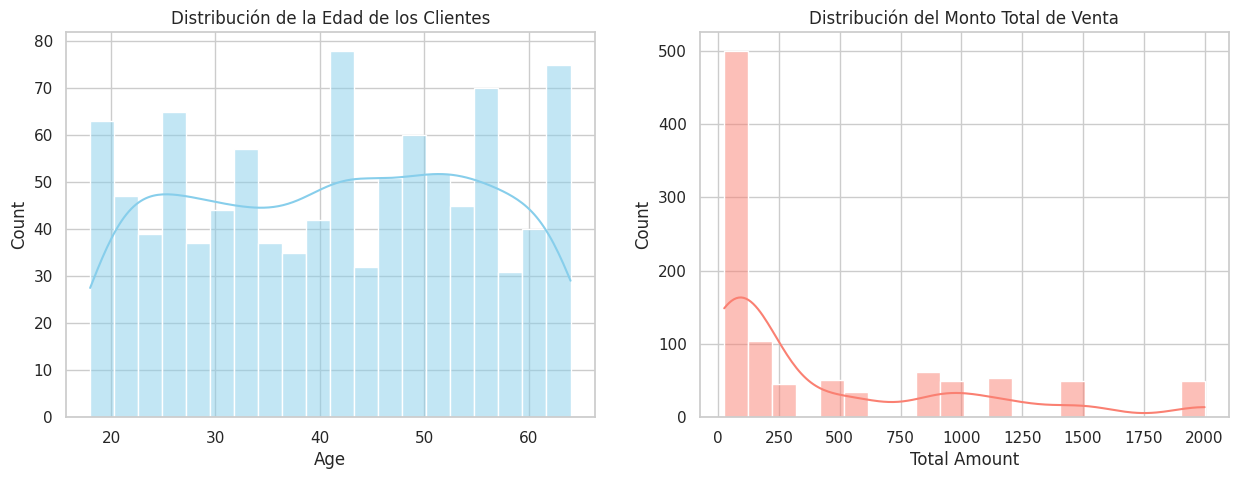

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Histogramas de Edad y Monto Total
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df_rs['Age'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de la Edad de los Clientes')

sns.histplot(df_rs['Total Amount'], bins=20, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribución del Monto Total de Venta')

plt.show()



**Analisis:**

En el histograma de la edad, se ve que hay una distribucion uniforme, cada barra tiene entre 20 y 30 registros por cada ranto de edad, lo que indica que no hay un segmento de edad que domine las ventas.

En el histograma del monto total de ventas, la distribucion esta sesgada a la derecha, con un pico cerca del cero y pequenos saltos en valores mas altos. Esto indica que la mayoria de las ventas son por montos bajos, y las ventas de montos altos son excepcionales.

/tmp/ipykernel_3360/2864489151.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Product Category', y='Total Amount', data=df_rs, palette='Set2')


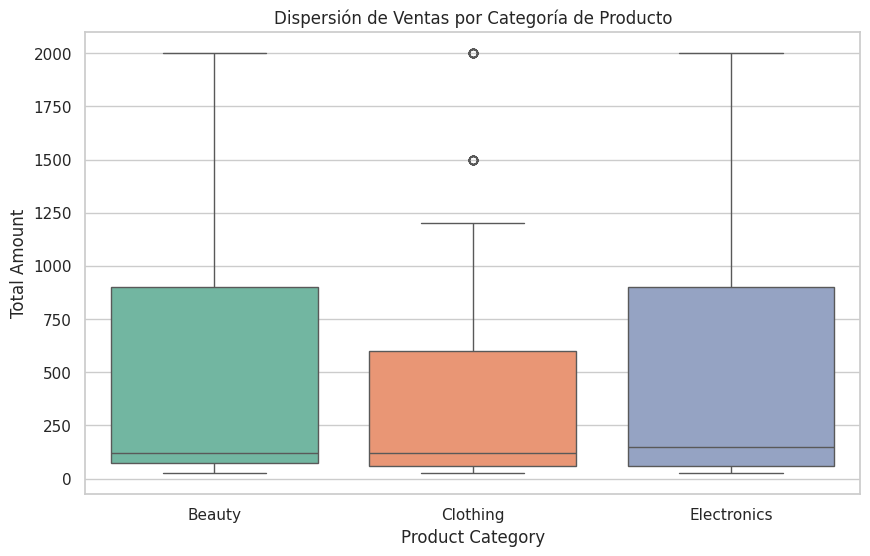

In [40]:
# Boxplot para detectar dispersión en categorías
plt.figure(figsize=(10, 6))
sns.boxplot(x='Product Category', y='Total Amount', data=df_rs, palette='Set2')
plt.title('Dispersión de Ventas por Categoría de Producto')
plt.show()

**Analisis**:

Las tres cajas son parecidas, lo que sugiere que el comportamiento de compra no varia por el tipo de producto y los precios de cada categoria estan en el mismo rango

La mediana de cada caja esta entre los 150-200 usd, es decir, el 50% de las ventas estan bajo ese valor.

Se observan outliers en la categoria de clothing, posiblemente debido a una compra de muchas unidades de algun producto especifico o un producto muy costoso, pero no definen el comportamiento promedio de los clientes de la tienda

Los bigotes se extienden desde el valor mínimo (~$25) hasta el máximo (~$500 o más dependiendo de la escala). Al ser tan largos comparados con la caja, confirman que hay mucha variabilidad en los precios: tienes desde artículos muy baratos hasta otros que valen 20 veces más.

In [41]:
# Filtrar los casos de outliers en ropa
outliers_clothing = df_rs[(df_rs['Product Category'] == 'Clothing') & (df_rs['Total Amount'] > 1000)]
print("Transacciones Atípicas en Ropa:")
print(outliers_clothing)

Transacciones Atípicas en Ropa:
     Transaction ID        Date Customer ID  Gender  Age Product Category  \
15               16  2023-02-17     CUST016    Male   19         Clothing   
57               58  2023-11-13     CUST058    Male   18         Clothing   
77               78  2023-07-01     CUST078  Female   47         Clothing   
106             107  2023-02-03     CUST107  Female   21         Clothing   
111             112  2023-12-02     CUST112    Male   37         Clothing   
114             115  2023-11-26     CUST115    Male   51         Clothing   
123             124  2023-10-27     CUST124    Male   33         Clothing   
164             165  2023-09-14     CUST165  Female   60         Clothing   
165             166  2023-04-02     CUST166    Male   34         Clothing   
201             202  2023-03-26     CUST202  Female   34         Clothing   
211             212  2023-06-09     CUST212    Male   21         Clothing   
214             215  2023-11-29     CUST215 

Son mas de 50 registros que superan los 1200 usd, con un precio por unidad entre 300-500 usd y una cantidad comprada de 3-4 unidades

Esto indica que la categoría de ropa tiene productos de "gama alta" que se venden bien en cantidades múltiples. No es un error de datos, es un segmento de clientes con alto poder adquisitivo.

Gráficos de líneas para mostrar las tendencias de ventas a lo largo del tiempo.

/tmp/ipykernel_3360/3423389937.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ventas_mensuales = df_rs.resample('M', on='Date')['Total Amount'].sum()


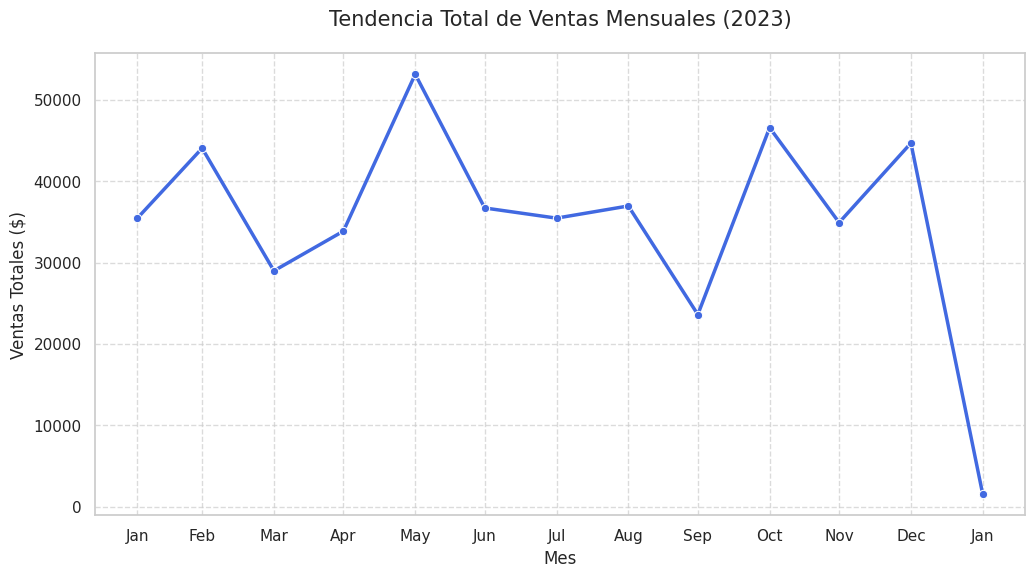

In [42]:
df_rs['Date'] = pd.to_datetime(df_rs['Date'])
# Agrupo las ventas por mes (Suma del Total Amount)
# 'M' significa agrupar por el último día de cada mes
ventas_mensuales = df_rs.resample('M', on='Date')['Total Amount'].sum()

plt.figure(figsize=(12, 6))
sns.lineplot(x=ventas_mensuales.index, y=ventas_mensuales.values, marker='o', color='royalblue', linewidth=2.5)

plt.title('Tendencia Total de Ventas Mensuales (2023)', fontsize=15, pad=20)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Ventas Totales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(ventas_mensuales.index, [d.strftime('%b') for d in ventas_mensuales.index])
plt.show()

**Analisis**

Mayo es el mejor mes para las ventas, luego entre junio - septiembre bajan notablemente, y vuelven a subir a partir de Octubre para volver a caer en Enero.


Gráficos de dispersión para analizar la relación entre diferentes variables.

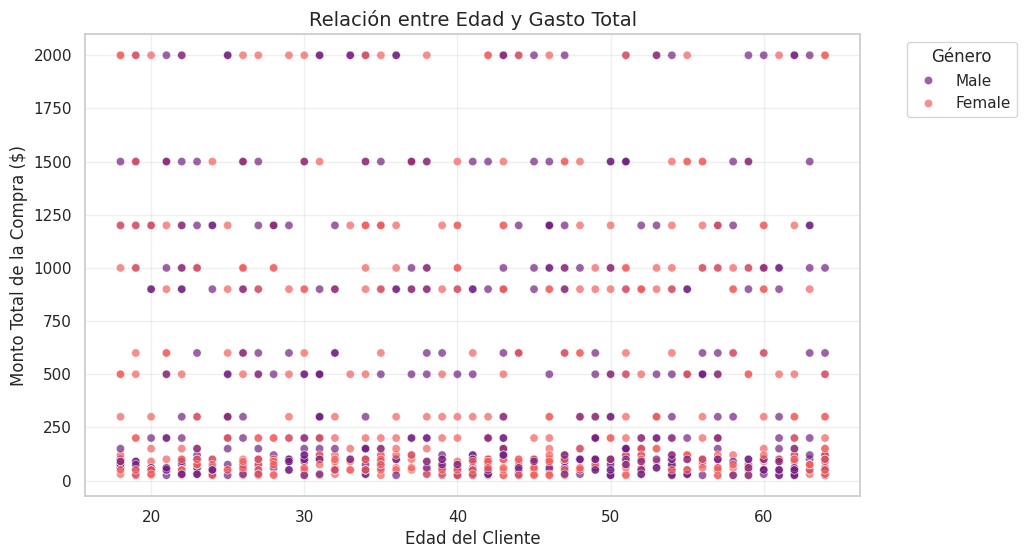

In [43]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_rs, x='Age', y='Total Amount', hue='Gender', alpha=0.7, palette='magma')

plt.title('Relación entre Edad y Gasto Total', fontsize=14)
plt.xlabel('Edad del Cliente', fontsize=12)
plt.ylabel('Monto Total de la Compra ($)', fontsize=12)
plt.legend(title='Género', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

**Analisis**

No existe una correlación entre la edad y el gasto.

El género tampoco es un factor determinante para el ticket promedio en esta tienda. Ambos segmentos se comportan de manera casi idéntica.

La mayor concentración de puntos (la zona más "sólida" de color) está en la parte inferior del gráfico, por debajo de los $500, lo que ratifica que las ventas de poco dinero representan el mayor ingreso del negocio

Histogramas y boxplots para visualizar la distribución de las ventas y detectar valores atípicos.

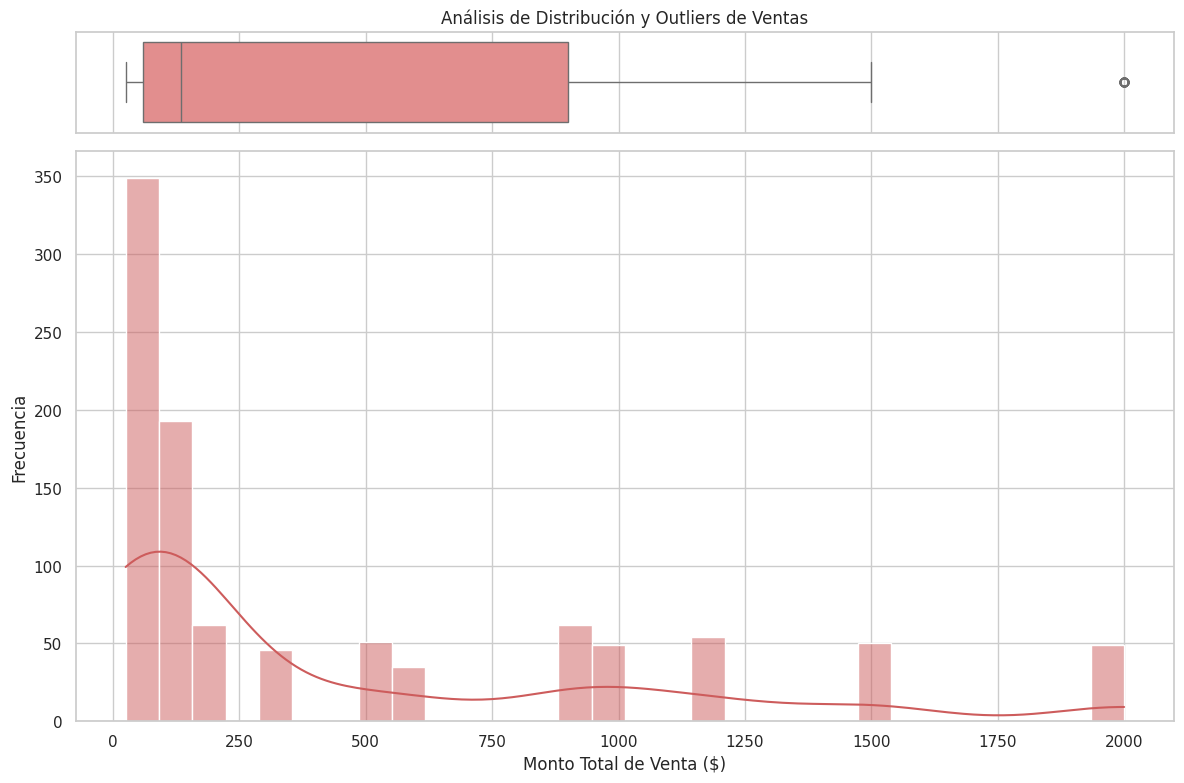

In [44]:
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(12, 8))

# Gráfico de Caja (Boxplot) horizontal en la parte superior
sns.boxplot(x=df_rs["Total Amount"], ax=ax_box, color='lightcoral', whis=1.0)
ax_box.set(title='Análisis de Distribución y Outliers de Ventas', xlabel='')

# Histograma con curva KDE en la parte inferior
sns.histplot(x=df_rs["Total Amount"], ax=ax_hist, kde=True, color='indianred', bins=30)
ax_hist.set(xlabel='Monto Total de Venta ($)', ylabel='Frecuencia')

plt.tight_layout()
plt.show()

**Analisis**

En el boxplot, los puntos aislados a la derecha de la línea del bigote confirman la existencia de valores atípicos.

En el histograma, esos mismos datos se ven como pequeñas "islas" o barras muy bajas después de los $1200.

La línea central de la "caja" está mucho más cerca de la izquierda que de la derecha, es decir tiene sesgo positivo

# **PARTE V**

Análisis de correlación y mapa de calor para visualizar las relaciones entre las variables.

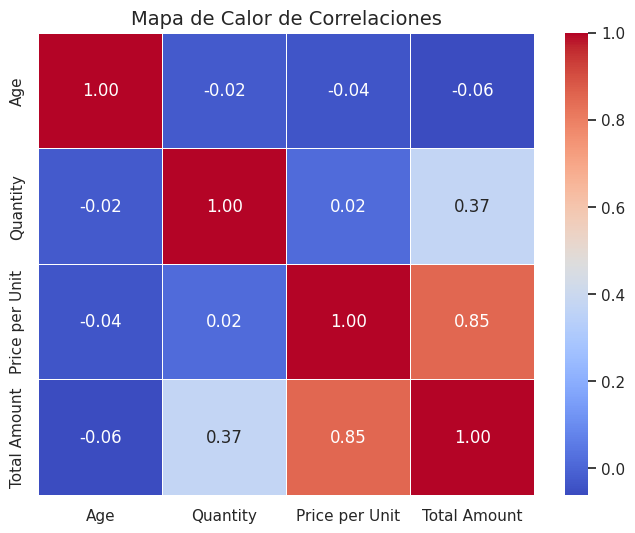

In [45]:
#columnas numéricas
numeric_df = df_rs[['Age', 'Quantity', 'Price per Unit', 'Total Amount']]

# matriz de correlación
corr_matrix = numeric_df.corr()

# Mapa de Calor (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones', fontsize=14)
plt.show()

**aNALISIS**

La correlación entre Price per Unit y Total Amount es de 0.85, y entre Quantity y Total Amount es de 0.36. Ño que confirma que el monto total de la venta depende mucho más del precio del producto que de la cantidad de unidades compradas.

Todos los valores contra Age son cercanos a 0.00, es decir la edad no influye en absoluto en el comportamiento de compra.

Subplots para comparar diferentes variables clave.

/tmp/ipykernel_3360/1279762316.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ventas_mensuales = df_rs.resample('M', on='Date')['Total Amount'].sum()


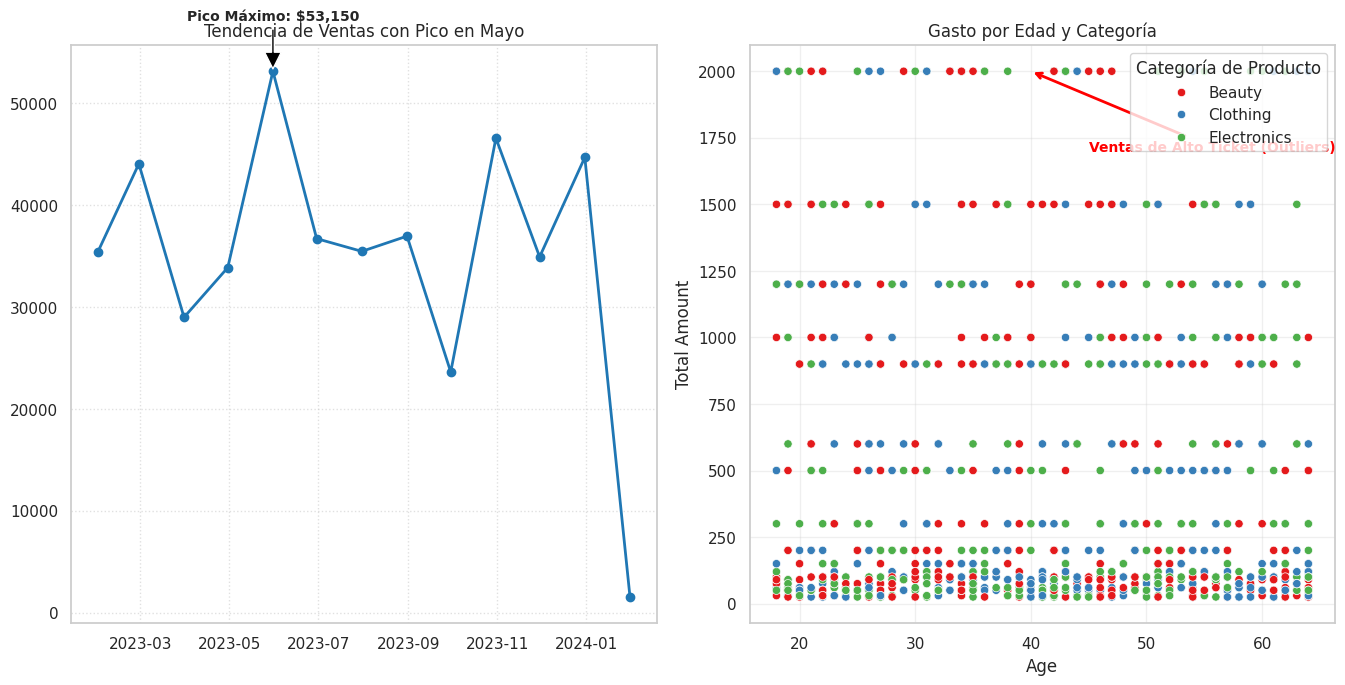

In [47]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Subplot 1- Tendencia Temporal
ventas_mensuales = df_rs.resample('M', on='Date')['Total Amount'].sum()
ax1.plot(ventas_mensuales.index, ventas_mensuales.values, marker='o', color='tab:blue', linewidth=2)
ax1.set_title('Tendencia de Ventas con Pico en Mayo')
ax1.grid(True, linestyle=':', alpha=0.6) # Cuadrícula

# Flecha y Anotación al pico de Mayo
pico_fecha = ventas_mensuales.idxmax()
pico_valor = ventas_mensuales.max()
ax1.annotate(f'Pico Máximo: ${pico_valor:,.0f}',
             xy=(pico_fecha, pico_valor),
             xytext=(pico_fecha, pico_valor + 5000),
             arrowprops=dict(facecolor='black', shrink=0.05, width=2),
             fontsize=10, fontweight='bold', ha='center')

# SUBPLOT 2: Relación Edad vs Gasto
sns.scatterplot(data=df_rs, x='Age', y='Total Amount', hue='Product Category', ax=ax2, palette='Set1')
ax2.set_title('Gasto por Edad y Categoría')
ax2.legend(title='Categoría de Producto', loc='upper right')
ax2.grid(True, alpha=0.3)

# Añadir Anotación sobre los Outliers de Clothing
ax2.annotate('Ventas de Alto Ticket (Outliers)',
             xy=(40, 2000),
             xytext=(45, 1700),
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             color='red', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()